# Exploratory Data Analysis of Stanford Dogs Dataset

Purpose: understand and analyze the dataset before making modelling decisions.
Insights will inform normalization, augmentation, and evaluation choices for modeling.

- [EDA](#eda)
  - [1. Imports & Setup](#1-imports--setup)
  - [2. Load Raw Dataset](#2-load-raw-dataset)
  - [3. Class Distribution](#3-class-distribution)
  - [4. Raw Image Dimensions](#4-raw-image-dimensions)
  - [5. Per-Channel Pixel Statistics](#5-per-channel-pixel-statistics)
  - [6. Visual Inspection Grid](#6-visual-inspection-grid)
  - [7. Confusable Breed Groups](#7-confusable-breed-groups)

## EDA

### 1. Imports & Setup

In [26]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from src.data.eda import class_counts, image_dimensions, pixel_stats, images_per_class, confusable_breeds

### 2. Load Raw Dataset

Stanford dataset is loaded here without `as_supervised` so full feature dictionary (filenames, bounding boxes) can be inspected if needed. 

In [27]:
(train_raw, test_raw), info = tfds.load('stanford_dogs', split=['train', 'test'], with_info=True, as_supervised=False, download=True)
num_classes = info.features['label'].num_classes
class_names_raw = info.features['label'].names
class_names = [n.split("-",1)[1] for n in class_names_raw]
train_ds = train_raw.map(lambda x: (x['image'], x['label']))
test_ds = test_raw.map(lambda x: (x['image'], x['label']))  

train_count = sum(1 for _ in train_ds)
test_count = sum(1 for _ in test_ds)
print(f"Class counts: {num_classes}")
print(f"Train sample count: {train_count}")
print(f"Test sample count: {test_count}")
print(f"\nFeatures:\n{info.features}\n")

Class counts: 120
Train sample count: 12000
Test sample count: 8580

Features:
FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=120),
    'objects': Sequence({
        'bbox': BBoxFeature(shape=(4,), dtype=float32),
    }),
})



### 3. Class Distribution

Stanford Dogs dataset contains 100 training images per class but test split is not evenly balanced. This will cause macro-averaged metrics like macro-F1 and per-class accuracy to be skewed by classes that have very few test samples. To interpret results properly it is important to identify which classes are underpresented in test split

In [28]:
train_counts = class_counts(train_ds, num_classes)
test_counts = class_counts(test_ds, num_classes)
print("Class distribution analysis for training set:")
print(f"    Total training samples: {train_counts.sum()}")
print(f"    Min samples in a class: {train_counts.min()}")
print(f"    Max samples in a class: {train_counts.max()}")
print(f"    Mean samples per class: {train_counts.mean():.2f}")

print("\nClass distribution analysis for test set:")
print(f"    Total test samples: {test_counts.sum()}")
print(f"    Min samples in a class: {test_counts.min()}")
print(f"    Max samples in a class: {test_counts.max()}")
print(f"    Mean samples per class: {test_counts.mean():.2f}")
print(f"    Imbalance ratio (test max/test min): {test_counts.max()/test_counts.min():.2f}")

Class distribution analysis for training set:
    Total training samples: 12000
    Min samples in a class: 100
    Max samples in a class: 100
    Mean samples per class: 100.00

Class distribution analysis for test set:
    Total test samples: 8580
    Min samples in a class: 48
    Max samples in a class: 152
    Mean samples per class: 71.50
    Imbalance ratio (test max/test min): 3.17


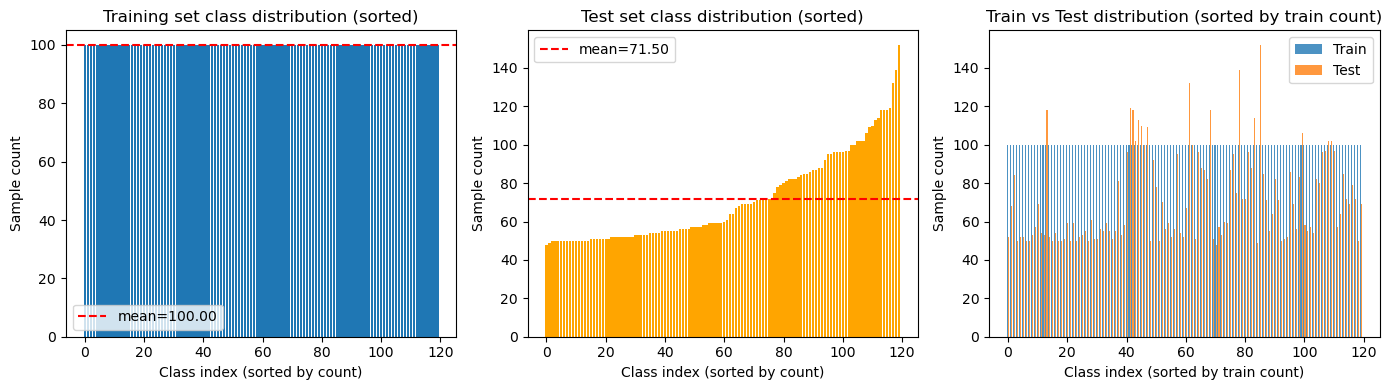

In [29]:
fig, ax = plt.subplots(1,3, figsize=(14,4))
train_idx_sorted = np.argsort(train_counts)
ax[0].bar(range(num_classes), train_counts[train_idx_sorted])
ax[0].set_title("Training set class distribution (sorted)")
ax[0].set_xlabel("Class index (sorted by count)")
ax[0].set_ylabel("Sample count")
ax[0].axhline(train_counts.mean(), color='red', linestyle='--', label=f'mean={train_counts.mean():.2f}')
ax[0].legend()

test_idx_sorted = np.argsort(test_counts)
ax[1].bar(range(num_classes), test_counts[test_idx_sorted], color='orange')
ax[1].set_title("Test set class distribution (sorted)")
ax[1].set_xlabel("Class index (sorted by count)")
ax[1].set_ylabel("Sample count")
ax[1].axhline(test_counts.mean(), color='red', linestyle='--', label=f'mean={test_counts.mean():.2f}')
ax[1].legend()

x = np.arange(num_classes)
width = 0.35

# sort both using training order for fair comparison
train_sorted = train_counts[train_idx_sorted]
test_sorted = test_counts[train_idx_sorted]
ax[2].bar(x-width/2, train_sorted, width, label='Train', alpha=0.8)
ax[2].bar(x+width/2, test_sorted,  width, label='Test',  alpha=0.8)
ax[2].set_title("Train vs Test distribution (sorted by train count)")
ax[2].set_xlabel("Class index (sorted by train count)")
ax[2].set_ylabel("Sample count")
ax[2].legend()
plt.tight_layout()
plt.show()

In [30]:
print("10 smallest test classes:")
for idx in test_idx_sorted[:10]:
    print(f"{class_names[idx]:>30s}: {test_counts[idx]} samples")

print("\n10 largest test classes:")
for idx in test_idx_sorted[-10:][::-1]:
    print(f"{class_names[idx]:>30s}: {test_counts[idx]} samples")

10 smallest test classes:
                       redbone: 48 samples
                      pekinese: 49 samples
                      malinois: 50 samples
           irish_water_spaniel: 50 samples
                        kuvasz: 50 samples
                   groenendael: 50 samples
                 border_collie: 50 samples
        welsh_springer_spaniel: 50 samples
                         dhole: 50 samples
          bouvier_des_flandres: 50 samples

10 largest test classes:
                   maltese_dog: 152 samples
                  afghan_hound: 139 samples
            scottish_deerhound: 132 samples
                    pomeranian: 119 samples
                       samoyed: 118 samples
               irish_wolfhound: 118 samples
          bernese_mountain_dog: 118 samples
                      shih-tzu: 114 samples
                great_pyrenees: 113 samples
                      leonberg: 110 samples


### 4. Raw Image Dimensions

All images are resized to 224x224 for the models.
The raw images are not mostly square which means during resizing a significant amount of information may be lost due to cropping and distortion.
It is important to quantify that trade-off and consider its impact on model performance.

In [31]:
dim_stats = image_dimensions(train_ds)
widths  = dim_stats['widths']
heights = dim_stats['heights']
aspects = dim_stats['aspects']
means = dim_stats['means']
stds = dim_stats['stds']
print(f"\nImage dimensison statistics of training set:")
print(f"    Width:  min={widths.min()}, max={widths.max()}, mean={widths.mean():.2f}, median={np.median(widths)}")
print(f"    Height: min={heights.min()}, max={heights.max()}, mean={heights.mean():.2f}, median={np.median(heights)}")
print(f"    Aspect ratio (W/H): min={aspects.min():.2f}, max={aspects.max():.2f}, mean={aspects.mean():.2f}, median={np.median(aspects):.2f}")
print(f"    Pixel means: {means.mean():.2f}")
print(f"    Pixel stds:  {stds.mean():.2f}")


Image dimensison statistics of training set:
    Width:  min=97, max=2740, mean=442.87, median=500.0
    Height: min=103, max=2560, mean=386.27, median=375.0
    Aspect ratio (W/H): min=0.42, max=2.80, mean=1.19, median=1.33
    Pixel means: 111.35
    Pixel stds:  60.79


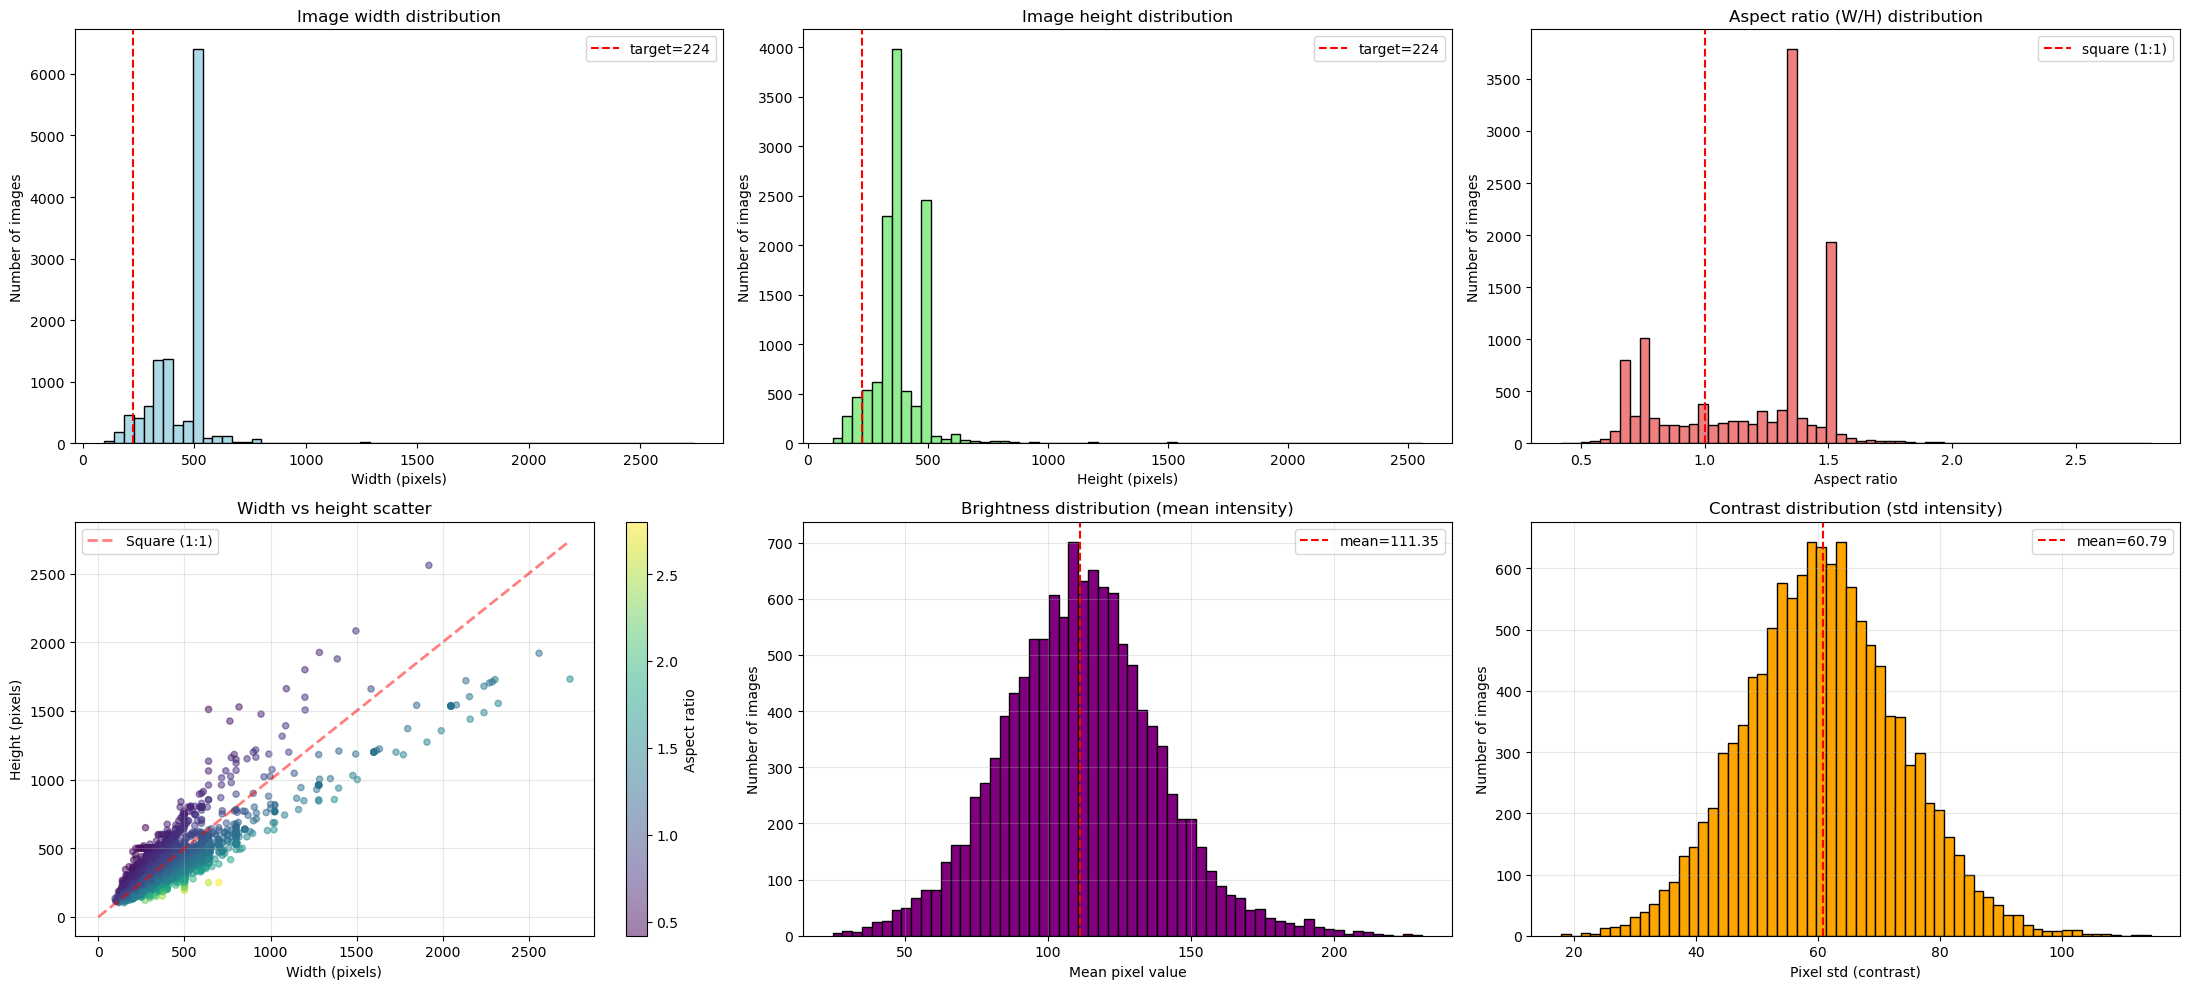

In [32]:
fig, ax = plt.subplots(2, 3, figsize=(22, 10))
ax[0,0].hist(widths, bins=60, color='lightblue', edgecolor='black')
ax[0,0].axvline(224, linestyle='--', color='red', label='target=224')
ax[0,0].set_title("Image width distribution")
ax[0,0].set_xlabel("Width (pixels)")
ax[0,0].set_ylabel("Number of images")
ax[0,0].legend()

ax[0,1].hist(heights, bins=60, color='lightgreen', edgecolor='black')
ax[0,1].axvline(224, linestyle='--', color='red', label='target=224')
ax[0,1].set_title("Image height distribution")
ax[0,1].set_xlabel("Height (pixels)")
ax[0,1].set_ylabel("Number of images")
ax[0,1].legend()

ax[0,2].hist(aspects, bins=60, color='lightcoral', edgecolor='black')
ax[0,2].axvline(1.0, linestyle='--', color='red', label='square (1:1)')
ax[0,2].set_title("Aspect ratio (W/H) distribution")
ax[0,2].set_xlabel("Aspect ratio")
ax[0,2].set_ylabel("Number of images")
ax[0,2].legend()

sc = ax[1,0].scatter(widths, heights, c=aspects, alpha=0.5, s=20)
ax[1,0].plot([0, max(widths)], [0, max(widths)], 'r--', linewidth=2, alpha=0.5, label='Square (1:1)')
ax[1,0].set_xlabel('Width (pixels)')
ax[1,0].set_ylabel('Height (pixels)')
ax[1,0].set_title('Width vs height scatter')
ax[1,0].legend()
ax[1,0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax[1, 0], label='Aspect ratio')

ax[1,1].hist(means, bins=60, color='purple', edgecolor='black')
ax[1,1].axvline(means.mean(), color='red', linestyle='--', label=f'mean={means.mean():.2f}')
ax[1,1].set_title("Brightness distribution (mean intensity)")
ax[1,1].set_xlabel("Mean pixel value")
ax[1,1].set_ylabel("Number of images")
ax[1,1].grid(True, alpha=0.3)
ax[1,1].legend()

ax[1,2].hist(stds, bins=60, color='orange', edgecolor='black')
ax[1,2].axvline(stds.mean(), color='red', linestyle='--', label=f'mean={stds.mean():.2f}')
ax[1,2].set_title("Contrast distribution (std intensity)")
ax[1,2].set_xlabel("Pixel std (contrast)")
ax[1,2].set_ylabel("Number of images")
ax[1,2].grid(True, alpha=0.3)
ax[1,2].legend()

plt.tight_layout()
plt.show()


### 5. Per-Channel Pixel Statistics

ResNet50 uses ImageNet’s fixed channel means but Stanford Dogs has different color statistics (lighting, background colors) which can affect transfer learning. For stable results, channel-wise mean and std are estimated from up to 2000 random images.


In [33]:
pixel_stats_train = pixel_stats(train_ds, max_samples=2000)
IMAGENET_MEANS = np.array([103.53, 116.28, 123.675], dtype=np.float32)
print("Channel        Stanford Dogs mean         ImageNet mean        (dogs-imagenet)")
for ch, name in enumerate(['R', 'G', 'B']):
    dog_mean = pixel_stats_train['channel_means'][ch]
    imagenet_mean = IMAGENET_MEANS[ch]
    diff = dog_mean - imagenet_mean
    print(f"  {name}              {dog_mean:10.2f}              {imagenet_mean:10.2f}            {diff:+10.2f}")

print(f"Channel stds: {pixel_stats_train['channel_stds']}")
print(f"Global range: [{pixel_stats_train['global_min']:.2f} , {pixel_stats_train['global_max']:.2f}] ")

Channel        Stanford Dogs mean         ImageNet mean        (dogs-imagenet)
  R                  118.53                  103.53                +15.00
  G                  114.08                  116.28                 -2.20
  B                   96.83                  123.68                -26.84
Channel stds: [66.99453 65.38437 66.80197]
Global range: [0.00 , 255.00] 


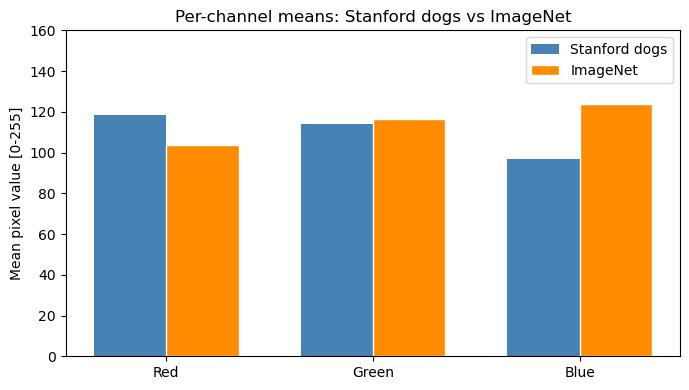

In [34]:
fig, ax = plt.subplots(figsize=(7,4))
channels = ['Red', 'Green', 'Blue']
x = np.arange(len(channels))
width = 0.35
ax.bar(x - width/2, pixel_stats_train['channel_means'], width, label='Stanford dogs', color='steelblue')
ax.bar(x + width/2, IMAGENET_MEANS, width, label='ImageNet', color='darkorange', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.set_ylabel('Mean pixel value [0-255]')
ax.set_title('Per-channel means: Stanford dogs vs ImageNet')
ax.legend()
ax.set_ylim(0, 160)
plt.tight_layout()
plt.show()

Stanford dogs has different color distribution than ImageNet, red channel is higher and blue channel is lower than ImageNet means. This mismatch affects feature transfer and normalization behavior when ImageNet pretrained models are used

### 6. Visual Inspection Grid



From dataset 12 classes are selected and 5 images from each are displayed.
This shows common challenges in dataset like  background clutter, multiple dogs and occlusions and watermarks that couls hinder model learning

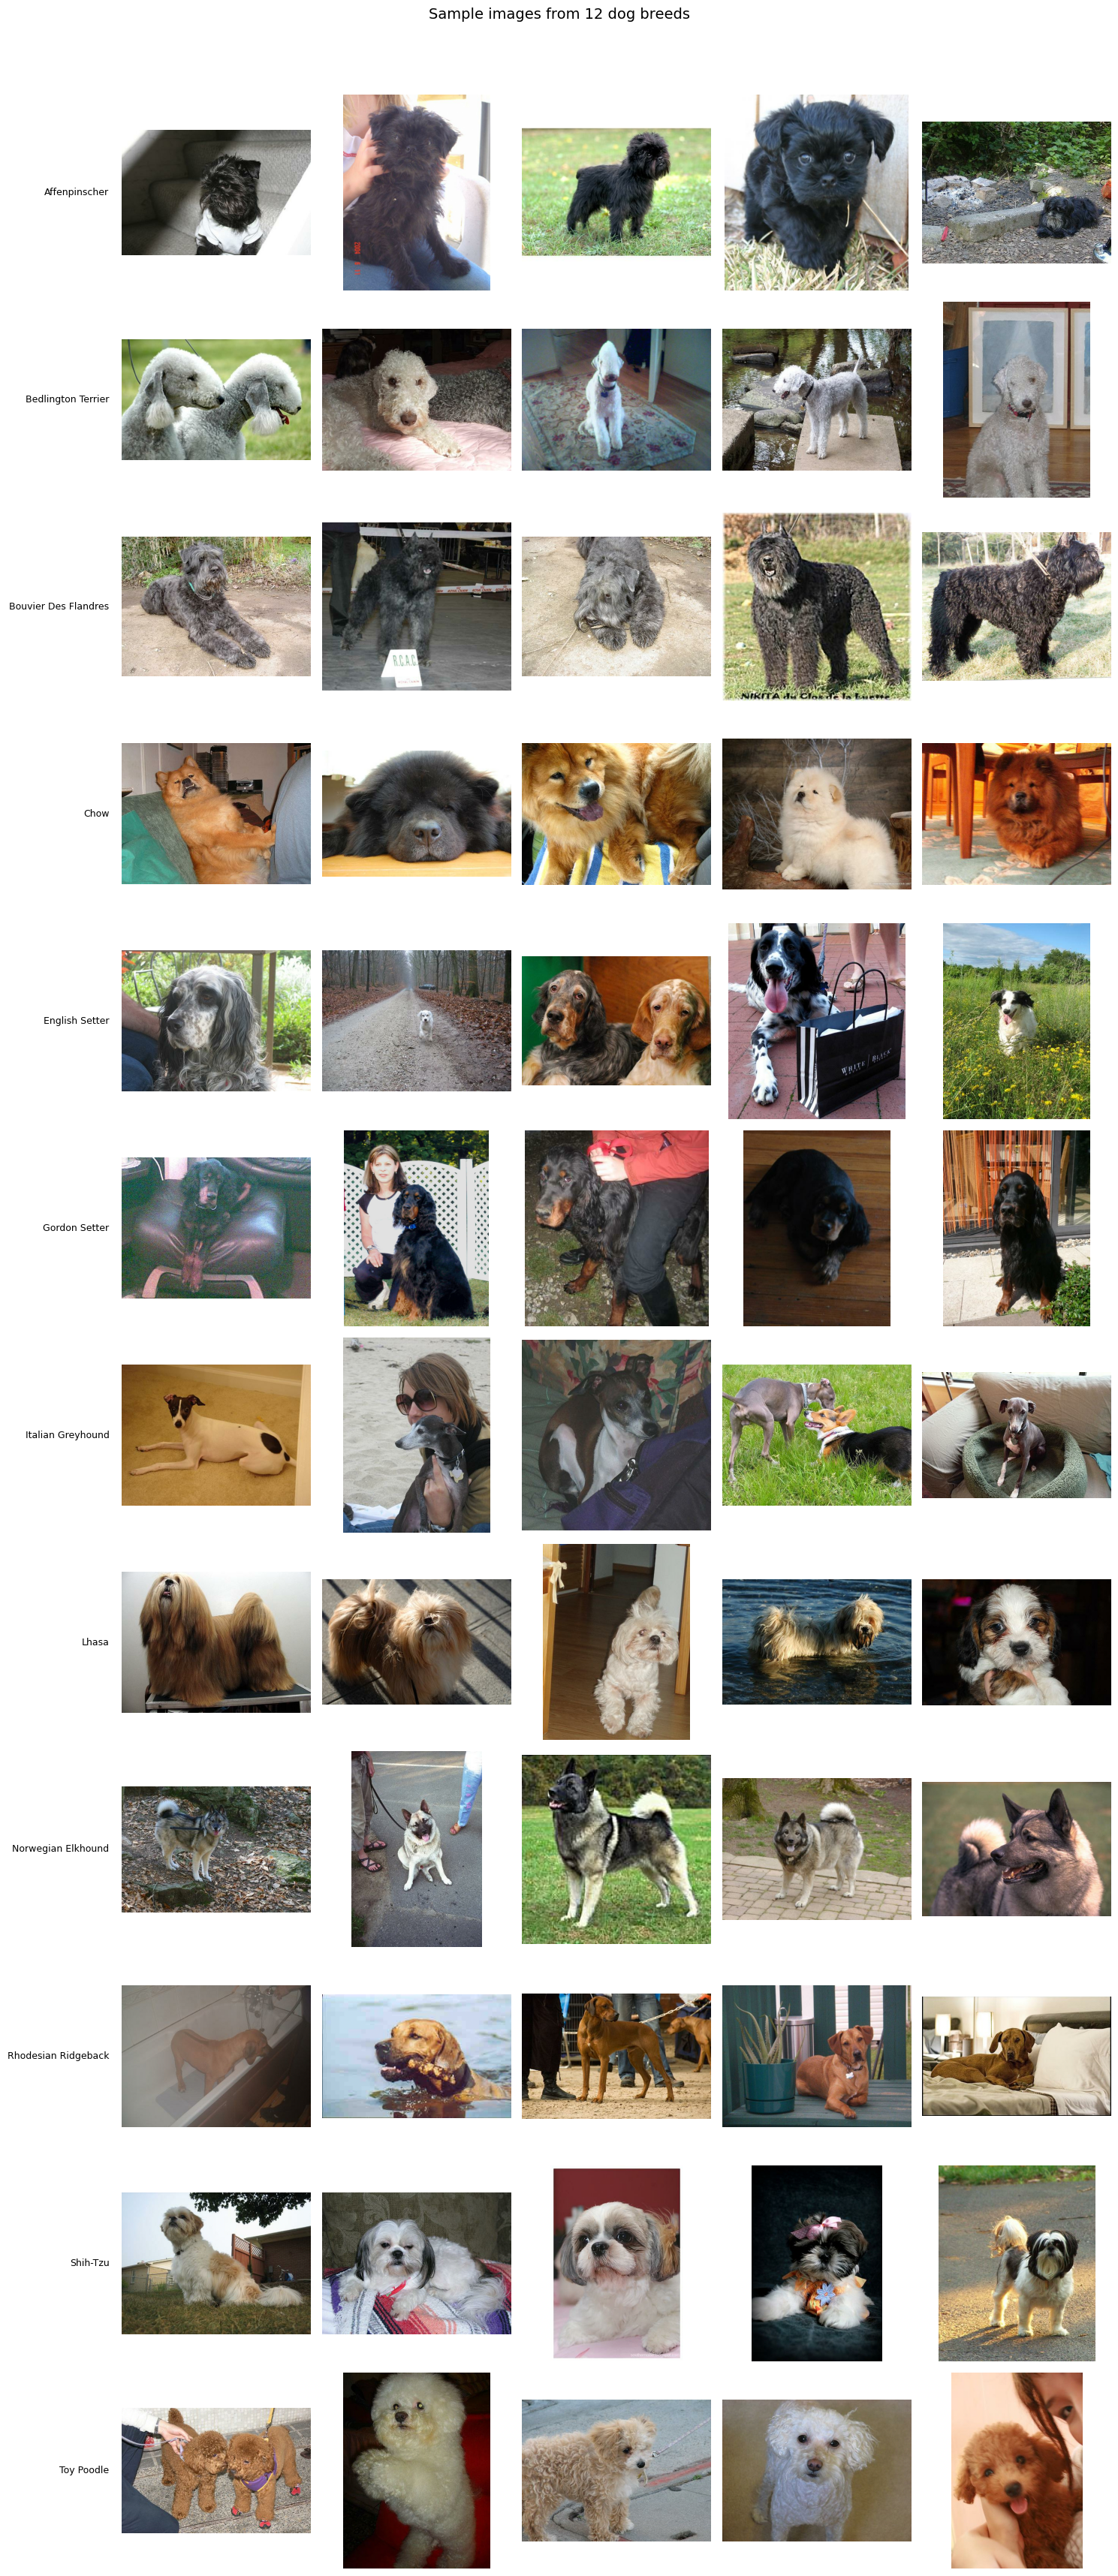

In [35]:
sorted_indices = sorted(range(num_classes), key=lambda i: class_names[i])
step = num_classes//12
target_classes = [sorted_indices[i*step] for i in range(12)]
N_PER_CLASS = 5
samples = images_per_class(train_ds, class_names, n_per_class=N_PER_CLASS, target_classes=target_classes)
n_plot_class = len(samples)
fig, axes = plt.subplots(n_plot_class, N_PER_CLASS, figsize=(N_PER_CLASS*3, n_plot_class*2.8))

for row, class_idx in enumerate(sorted(samples.keys(), key=lambda i: samples[i]["name"])):
    name = samples[class_idx]["name"].replace("_", " ").title()
    images = samples[class_idx]["images"]
    for col in range(N_PER_CLASS):
        ax = axes[row, col]
        if col < len(images):
            ax.imshow(images[col])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if col == 0:
            ax.set_ylabel(name, rotation=0, labelpad=12, fontsize=9, ha="right", va="center")

fig.suptitle(f"Sample images from {n_plot_class} dog breeds", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7. Confusable Breed Groups

Fine-grained classification is especially difficult for breeds that belong to the same family such as different spaniel sub-breeds or retriever group. List of these groups tells where to focus when analyzing confusion matrix, since it is where the model is most likely to make mistakes.

In [36]:
confusables = confusable_breeds(class_names)
print("Most confusable dog breeds:")
for i, (keyword, breeds) in enumerate(confusables.items()):
    print(f"\n{i+1}. Family: '{keyword.upper()}' ({len(breeds)} breeds)")
    for breed in breeds:
        print(f"          - {breed}")

Most confusable dog breeds:

1. Family: 'SPANIEL' (7 breeds)
          - blenheim_spaniel
          - brittany_spaniel
          - cocker_spaniel
          - irish_water_spaniel
          - japanese_spaniel
          - sussex_spaniel
          - welsh_springer_spaniel

2. Family: 'RETRIEVER' (5 breeds)
          - chesapeake_bay_retriever
          - curly-coated_retriever
          - flat-coated_retriever
          - golden_retriever
          - labrador_retriever

3. Family: 'TERRIER' (19 breeds)
          - american_staffordshire_terrier
          - australian_terrier
          - bedlington_terrier
          - border_terrier
          - irish_terrier
          - kerry_blue_terrier
          - lakeland_terrier
          - norfolk_terrier
          - norwich_terrier
          - scotch_terrier
          - sealyham_terrier
          - silky_terrier
          - soft-coated_wheaten_terrier
          - staffordshire_bullterrier
          - tibetan_terrier
          - toy_terrier
          

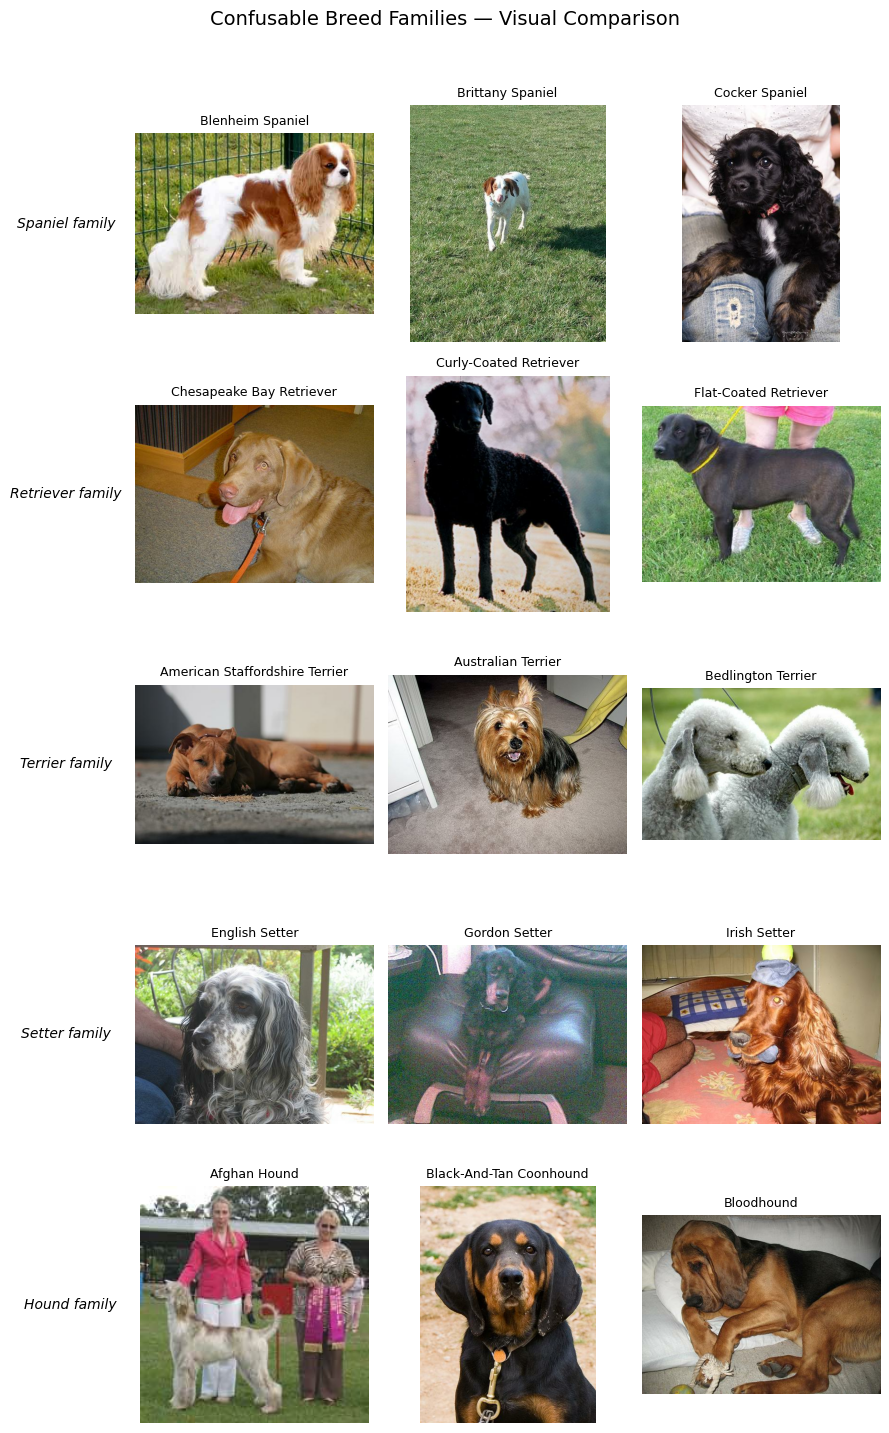

In [37]:
# show one row of 3 images per family so we can see the similarity
all_target_indices = []
for keyword, breeds in confusables.items():
    for breed in breeds[:3]:
        idx = class_names.index(breed)
        all_target_indices.append(idx)

confusable_samples = images_per_class(
    train_ds, class_names, n_per_class=2, target_classes=all_target_indices)

max_breeds = 3
n_rows = len(confusables)
n_cols = max_breeds

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3, n_rows * 2.8),
    squeeze=False
)

for row, (family, breeds) in enumerate(confusables.items()):
    for col, breed in enumerate(breeds[:max_breeds]):
        ax = axes[row, col]
        idx = class_names.index(breed)

        if idx in confusable_samples:
            images = confusable_samples[idx]["images"]
            ax.imshow(images[0])  # one image per breed

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Breed label under each image
        ax.set_title(
            class_names[idx].replace("_", " ").title(),
            fontsize=9
        )

    # Family label on the left
    axes[row, 0].set_ylabel(
        f"{family.title()} family",
        rotation=0,
        labelpad=50,
        fontsize=10,
        fontstyle="italic",
        va="center"
    )

fig.suptitle(
    "Confusable Breed Families — Visual Comparison",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


### 8. Summary

 - Test set imbalance makes macro metrics unreliable and misleading, weighted and per-class metrics can be used

 - Small test clases have very few samples, so per-class results can be noisy

 - Color distribution differs from ImageNet, channel means are shifted that can affect normalization so dataset specific normalization can be considered whin fine-tuning

 - Errors will mostly occur withtin breed families such as terriers, spaniels, retrievers, setters and hounds

 - Data quality is realistic but challenging: aspect ratio distortion, clutter, occlusions, pose and lighting variation are present.

